# Notebook 05 — KaelvorNet Explainability

# Saliency, Scalp Topomaps, and a Subject-Invariance Probe

---

## Purpose

Three explainability analyses for KaelvorNet:

1. **Integrated Gradients** (channel x time importance) — which channels and time points
   drive each class prediction, per trial and averaged per class.
2. **Scalp topomaps** — the same importance, aggregated over time and projected onto the
   22-channel scalp layout, per class.
3. **Subject-invariance probe** — a direct empirical test of KaelvorNet's central claim:
   train a simple linear probe to predict *subject identity* from the shared backbone's
   features, comparing a GRL-trained backbone against a plain EEGNet backbone (no GRL). If
   the domain-adversarial training worked, the probe should do noticeably worse on the
   GRL-trained features.

**Note on channel count:** earlier notebooks' `extract_epochs()` didn't restrict picks to
EEG-only, so they trained on 25 channels (22 EEG + 3 EOG) rather than 22. This notebook
restricts to `picks="eeg"` (22 channels) since the topomap needs exact channel identities —
worth carrying that fix back to the other notebooks too if you want fully consistent numbers.

**This is a standalone notebook.** Same input setup as the others (Add Input -> your
preprocessing notebook, optionally + true_labels dataset).

In [1]:
# Kaggle notebooks don't have mne preinstalled by default
!pip install -q mne

In [2]:
# ==========================================================
# Imports
# ==========================================================

import re
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
import mne

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.autograd import Function

from sklearn.metrics import accuracy_score, cohen_kappa_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from scipy.linalg import fractional_matrix_power

import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


In [3]:
# ==========================================================
# Configuration — auto-discover inputs
# ==========================================================

INPUT_ROOT = Path("/kaggle/input")
OUTPUT_PATH = Path("/kaggle/working")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

fif_files = sorted(INPUT_ROOT.rglob("*.fif"))
mat_search_root = INPUT_ROOT

print(f"Found {len(fif_files)} preprocessed .fif file(s):")
for f in fif_files[:10]:
    print(" ", f)

if not fif_files:
    print("\nNo .fif files found. Everything currently under /kaggle/input:\n")
    if INPUT_ROOT.exists():
        for p in sorted(INPUT_ROOT.rglob("*")):
            print(" ", p)
    raise FileNotFoundError(
        "No .fif files found under /kaggle/input. Make sure the preprocessing notebook was "
        "committed via 'Save Version -> Save & Run All (Commit)' and added here as a Notebook "
        "input."
    )

CUE_CODE_TO_LABEL = {"769": 0, "770": 1, "771": 2, "772": 3}
CLASS_NAMES = {0: "Left Hand", 1: "Right Hand", 2: "Foot", 3: "Tongue"}

BCI2A_EEG_ORDER = [
    'Fz', 'FC3','FC1','FCz','FC2','FC4',
    'C5','C3','C1','Cz','C2','C4','C6',
    'CP3','CP1','CPz','CP2','CP4',
    'P1','Pz','P2', 'POz'
]

mi_files = [f for f in fif_files if f.stem.upper().endswith("T")]
eval_files = [f for f in fif_files if f.stem.upper().endswith("E")]

subjects_covered = sorted({f.stem[:-1] for f in mi_files})
subject_ids_all = {sid: i for i, sid in enumerate(subjects_covered)}
n_subjects_total = len(subject_ids_all)

print(f"\nSubjects with a training file ({n_subjects_total}): {subjects_covered}")

Found 18 preprocessed .fif file(s):
  /kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A01/A01E.fif
  /kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A01/A01T.fif
  /kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A02/A02E.fif
  /kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A02/A02T.fif
  /kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A03/A03E.fif
  /kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A03/A03T.fif
  /kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A04/A04E.fif
  /kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A04/A04T.fif
  /kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A05/A05E.fif
  /kaggle/input/notebooks/sababahoque

In [4]:
# ==========================================================
# Epoch extraction (EEG-only -- 22 channels, needed for topomap plotting)
# ==========================================================

def extract_epochs(fif_file):

    raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    cue_id = {k: v for k, v in event_id.items() if k in CUE_CODE_TO_LABEL}

    if not cue_id:
        raise ValueError(f"No motor-imagery cue codes found in {fif_file.name}.")

    epochs = mne.Epochs(
        raw, events, event_id=cue_id, tmin=-0.5, tmax=4.0,
        baseline=(-0.5, 0), preload=True, reject_by_annotation=True,
        picks="eeg", verbose=False
    )

    X = epochs.get_data()
    inv_cue_id = {v: k for k, v in cue_id.items()}
    y = np.array([CUE_CODE_TO_LABEL[inv_cue_id[c]] for c in epochs.events[:, 2]])

    return X, y, epochs.ch_names


def extract_epochs_eval(fif_file):

    raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    eval_cue_id = {k: v for k, v in event_id.items() if k == "783"}

    if not eval_cue_id:
        raise ValueError(f"No 'unknown' (783) cue markers found in {fif_file.name}.")

    epochs = mne.Epochs(
        raw, events, event_id=eval_cue_id, tmin=-0.5, tmax=4.0,
        baseline=(-0.5, 0), preload=True, reject_by_annotation=True,
        picks="eeg", verbose=False
    )

    return epochs.get_data()


def find_true_labels(subject_id, search_root):

    candidates = list(Path(search_root).rglob(f"{subject_id}E.mat"))
    if not candidates:
        return None

    mat = sio.loadmat(candidates[0])
    key = "classlabel" if "classlabel" in mat else next(
        (k for k in mat if not k.startswith("__")), None
    )
    if key is None:
        return None

    return np.array(mat[key]).squeeze().astype(int) - 1

In [5]:
# ==========================================================
# Euclidean Alignment
# ==========================================================

def compute_alignment_matrix(X):

    n_trials, n_channels, n_samples = X.shape
    covs = np.array([(trial @ trial.T) / n_samples for trial in X])
    mean_cov = covs.mean(axis=0)

    return fractional_matrix_power(mean_cov, -0.5).real


def apply_alignment(X, R_inv_sqrt):

    return np.einsum("cd,ndt->nct", R_inv_sqrt, X)


def euclidean_align(X_ref, *X_others):

    R_inv_sqrt = compute_alignment_matrix(X_ref)
    aligned = [apply_alignment(X_ref, R_inv_sqrt)]
    for X in X_others:
        aligned.append(apply_alignment(X, R_inv_sqrt))

    return aligned

In [6]:
# ==========================================================
# Gradient Reversal Layer + KaelvorNet (same architecture as before)
# ==========================================================

class GradientReversalFunction(Function):

    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.lambda_, None


class GradientReversalLayer(nn.Module):

    def __init__(self, lambda_=1.0):
        super().__init__()
        self.lambda_ = lambda_

    def forward(self, x):
        return GradientReversalFunction.apply(x, self.lambda_)


class EEGNetBackbone(nn.Module):

    def __init__(self, n_channels=22, n_samples=1126, sfreq=250, F1=8, D=2, F2=16, dropout=0.5):
        super().__init__()

        half_sfreq = max(int(sfreq // 2), 1)

        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, half_sfreq), padding=(0, half_sfreq // 2), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1 * D, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, (1, 16), padding=(0, 8), groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_samples)
            out = self.block2(self.block1(dummy))
            self.feature_dim = out.numel()

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.block1(x)
        x = self.block2(x)
        return x.flatten(start_dim=1)


class SubjectAdapter(nn.Module):

    def __init__(self, feature_dim):
        super().__init__()
        self.norm = nn.BatchNorm1d(feature_dim, affine=True)

    def forward(self, x):
        return self.norm(x)


class KaelvorNet(nn.Module):

    def __init__(self, n_channels=22, n_classes=4, n_samples=1126, sfreq=250,
                 n_subjects=9, use_domain_head=True, use_adapter=True, grl_lambda=1.0):
        super().__init__()

        self.use_domain_head = use_domain_head
        self.use_adapter = use_adapter

        self.backbone = EEGNetBackbone(n_channels=n_channels, n_samples=n_samples, sfreq=sfreq)
        feat_dim = self.backbone.feature_dim

        if use_adapter:
            self.adapter = SubjectAdapter(feat_dim)

        self.classifier = nn.Linear(feat_dim, n_classes)

        if use_domain_head:
            self.grl = GradientReversalLayer(lambda_=grl_lambda)
            self.domain_head = nn.Sequential(
                nn.Linear(feat_dim, 32),
                nn.ELU(),
                nn.Linear(32, n_subjects),
            )

    def set_grl_lambda(self, lambda_):
        if self.use_domain_head:
            self.grl.lambda_ = lambda_

    def get_features(self, x):
        """Backbone features before the adapter -- what the domain head sees."""
        return self.backbone(x)

    def forward(self, x, return_domain_logits=False, return_features=False):

        features = self.backbone(x)
        adapted = self.adapter(features) if self.use_adapter else features
        class_logits = self.classifier(adapted)

        if return_domain_logits and self.use_domain_head:
            domain_logits = self.domain_head(self.grl(features))
            if return_features:
                return class_logits, domain_logits, features
            return class_logits, domain_logits

        if return_features:
            return class_logits, features

        return class_logits

In [7]:
# ==========================================================
# Training Helper
# ==========================================================

def normalize(X, mean, std):
    return (X - mean) / std


def train_kaelvornet(X_train, y_train, subj_train, X_test, y_test, n_subjects,
                      use_domain_head=True, use_adapter=True,
                      n_epochs=100, batch_size=32, lr=1e-3, grl_lambda_max=1.0, verbose=True):

    mean = X_train.mean(axis=(0, 2), keepdims=True)
    std = X_train.std(axis=(0, 2), keepdims=True) + 1e-8

    X_train_n = normalize(X_train, mean, std)
    X_test_n = normalize(X_test, mean, std)

    X_train_t = torch.tensor(X_train_n, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)
    subj_train_t = torch.tensor(subj_train, dtype=torch.long)
    X_test_t = torch.tensor(X_test_n, dtype=torch.float32).to(DEVICE)

    train_ds = TensorDataset(X_train_t, y_train_t, subj_train_t)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    model = KaelvorNet(
        n_channels=X_train.shape[1], n_classes=len(CLASS_NAMES), n_samples=X_train.shape[2],
        n_subjects=n_subjects, use_domain_head=use_domain_head, use_adapter=use_adapter,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    task_criterion = nn.CrossEntropyLoss()
    domain_criterion = nn.CrossEntropyLoss()

    model.train()

    for epoch in range(n_epochs):

        p = epoch / max(n_epochs - 1, 1)
        lambda_ = grl_lambda_max * (2.0 / (1.0 + np.exp(-10 * p)) - 1.0)
        model.set_grl_lambda(lambda_)

        epoch_loss = 0.0

        for xb, yb, sb in train_loader:

            xb, yb, sb = xb.to(DEVICE), yb.to(DEVICE), sb.to(DEVICE)
            optimizer.zero_grad()

            if use_domain_head:
                class_logits, domain_logits = model(xb, return_domain_logits=True)
                loss = task_criterion(class_logits, yb) + domain_criterion(domain_logits, sb)
            else:
                class_logits = model(xb)
                loss = task_criterion(class_logits, yb)

            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)

        if verbose and ((epoch + 1) % 25 == 0 or epoch == 0):
            print(f"    epoch {epoch+1}/{n_epochs}  loss={epoch_loss/len(train_ds):.4f}")

    model.eval()

    with torch.no_grad():
        preds = model(X_test_t).argmax(dim=1).cpu().numpy()

    acc = accuracy_score(y_test, preds)
    kappa = cohen_kappa_score(y_test, preds)

    return acc, kappa, model, (mean, std)

---
## Setup — Train Two Models for Comparison

A held-out subject is picked (leave-one-subject-out, zero-shot, same as the main KaelvorNet
notebook): pretrain **(a)** full KaelvorNet (EA + GRL + adapter) and **(b)** a plain EEGNet
(no EA, no GRL, no adapter) on the other 8 subjects, and evaluate both on the held-out
subject's test trials. Both models feed everything downstream — the held-out subject's
correctly-classified trials go into the saliency/topomap analysis, and both models' backbone
features go into the subject-invariance probe.

In [8]:
# ==========================================================
# Pick a held-out subject and build the two models
# ==========================================================

HELD_OUT_SUBJECT = subjects_covered[0]   # change this to inspect a different subject

train_subject_ids = [s for s in subjects_covered if s != HELD_OUT_SUBJECT]

def build_pool(subject_ids, use_ea):

    X_pool, y_pool, subj_pool = [], [], []

    for sid in subject_ids:

        t_file = next(f for f in mi_files if f.stem[:-1] == sid)
        X_s, y_s, ch_names = extract_epochs(t_file)

        if use_ea:
            X_s, = euclidean_align(X_s)

        X_pool.append(X_s)
        y_pool.append(y_s)
        subj_pool.append(np.full(len(y_s), subject_ids_all[sid]))

    return (np.concatenate(X_pool, axis=0), np.concatenate(y_pool, axis=0),
            np.concatenate(subj_pool, axis=0), ch_names)


e_file_ho = next((f for f in eval_files if f.stem[:-1] == HELD_OUT_SUBJECT), None)
if e_file_ho is None:
    raise ValueError(f"No matching *E file found for {HELD_OUT_SUBJECT}.")

true_labels = find_true_labels(HELD_OUT_SUBJECT, mat_search_root)
used_fallback = true_labels is None

def get_held_out_test(use_ea):

    if used_fallback:
        t_file_ho = next(f for f in mi_files if f.stem[:-1] == HELD_OUT_SUBJECT)
        X_ho, y_ho, ch_names = extract_epochs(t_file_ho)
        _, X_test, _, y_test = train_test_split(
            X_ho, y_ho, test_size=0.7, stratify=y_ho, random_state=SEED
        )
    else:
        X_test = extract_epochs_eval(e_file_ho)
        y_test = true_labels
        _, _, _, ch_names = build_pool([train_subject_ids[0]], use_ea=False)

    if use_ea:
        X_test, = euclidean_align(X_test)

    return X_test, y_test, ch_names


print(f"Held-out subject: {HELD_OUT_SUBJECT} "
      f"({'fallback' if used_fallback else 'official'} split)\n")

# ---- (a) Full KaelvorNet ----
print("Training full KaelvorNet (EA + GRL + adapter)...")
X_pool_a, y_pool_a, subj_pool_a, ch_names = build_pool(train_subject_ids, use_ea=True)
X_test_a, y_test_a, _ = get_held_out_test(use_ea=True)

acc_full, kappa_full, model_full, (mean_full, std_full) = train_kaelvornet(
    X_pool_a, y_pool_a, subj_pool_a, X_test_a, y_test_a,
    n_subjects=n_subjects_total, use_domain_head=True, use_adapter=True
)
print(f"Full KaelvorNet: acc={acc_full:.3f}  kappa={kappa_full:.3f}\n")

# ---- (b) Plain EEGNet (no EA, no GRL, no adapter) ----
print("Training plain EEGNet (no EA, no GRL, no adapter)...")
X_pool_b, y_pool_b, subj_pool_b, _ = build_pool(train_subject_ids, use_ea=False)
X_test_b, y_test_b, _ = get_held_out_test(use_ea=False)

acc_plain, kappa_plain, model_plain, (mean_plain, std_plain) = train_kaelvornet(
    X_pool_b, y_pool_b, subj_pool_b, X_test_b, y_test_b,
    n_subjects=n_subjects_total, use_domain_head=False, use_adapter=False
)
print(f"Plain EEGNet: acc={acc_plain:.3f}  kappa={kappa_plain:.3f}")

Held-out subject: A01 (fallback split)

Training full KaelvorNet (EA + GRL + adapter)...


/tmp/ipykernel_16/47796158.py:7: RuntimeWarning: This filename (/kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A02/A02T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
/tmp/ipykernel_16/47796158.py:7: RuntimeWarning: This filename (/kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A03/A03T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
/tmp/ipykernel_16/47796158.py:7: RuntimeWarning: This filename (/kaggle/input/no

    epoch 1/100  loss=3.3113
    epoch 25/100  loss=3.0594
    epoch 50/100  loss=2.9092
    epoch 75/100  loss=2.9157
    epoch 100/100  loss=2.9631
Full KaelvorNet: acc=0.693  kappa=0.591

Training plain EEGNet (no EA, no GRL, no adapter)...


/tmp/ipykernel_16/47796158.py:7: RuntimeWarning: This filename (/kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A02/A02T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
/tmp/ipykernel_16/47796158.py:7: RuntimeWarning: This filename (/kaggle/input/notebooks/sababahoquesaba/eeg-preprocessing-pipeline/preprocessed_dataset/A03/A03T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
/tmp/ipykernel_16/47796158.py:7: RuntimeWarning: This filename (/kaggle/input/no

    epoch 1/100  loss=1.3903
    epoch 25/100  loss=0.8996
    epoch 50/100  loss=0.8046
    epoch 75/100  loss=0.7642
    epoch 100/100  loss=0.7362
Plain EEGNet: acc=0.668  kappa=0.558


---
## 1. Integrated Gradients (Channel x Time Importance)

Manual Integrated Gradients implementation (no extra dependency beyond PyTorch): interpolate
linearly from an all-zero baseline to the actual input, average the gradient of the predicted
class's logit along that path, and scale by (input - baseline). Averaged over correctly
classified held-out-subject trials, per class.

In [9]:
# ==========================================================
# Integrated Gradients
# ==========================================================

def integrated_gradients(model, x, target_class, steps=50, baseline=None):
    """
    x: (1, n_channels, n_samples) tensor, already normalized the same way the model was trained.
    Returns an attribution map of the same shape as x.
    """

    if baseline is None:
        baseline = torch.zeros_like(x)

    alphas = torch.linspace(0, 1, steps).to(x.device)

    total_grad = torch.zeros_like(x)

    for alpha in alphas:

        interpolated = baseline + alpha * (x - baseline)
        interpolated.requires_grad_(True)

        logits = model(interpolated)
        target_logit = logits[0, target_class]

        grad = torch.autograd.grad(target_logit, interpolated)[0]
        total_grad += grad

    avg_grad = total_grad / steps

    return (x - baseline) * avg_grad


def compute_class_saliency(model, X_test_norm, y_test, y_pred, class_id, max_trials=20):
    """
    Averages Integrated Gradients attribution over up to max_trials correctly-classified
    trials of the given class. Returns a (n_channels, n_samples) numpy array.
    """

    idx = np.where((y_test == class_id) & (y_pred == class_id))[0][:max_trials]

    if len(idx) == 0:
        print(f"  No correctly classified trials for class {CLASS_NAMES[class_id]} -- skipping.")
        return None

    attributions = []

    for i in idx:

        x = torch.tensor(X_test_norm[i:i+1], dtype=torch.float32, device=DEVICE)
        attr = integrated_gradients(model, x, class_id)
        attributions.append(attr.detach().cpu().numpy()[0])

    return np.mean(attributions, axis=0)  # (n_channels, n_samples)

In [10]:
# ==========================================================
# Run Integrated Gradients per class (full KaelvorNet, held-out subject)
# ==========================================================

X_test_a_norm = normalize(X_test_a, mean_full, std_full)

with torch.no_grad():
    X_test_a_t = torch.tensor(X_test_a_norm, dtype=torch.float32).to(DEVICE)
    y_pred_full = model_full(X_test_a_t).argmax(dim=1).cpu().numpy()

class_saliency = {}

for class_id, class_name in CLASS_NAMES.items():
    print(f"Computing Integrated Gradients for class: {class_name}")
    saliency = compute_class_saliency(model_full, X_test_a_norm, y_test_a, y_pred_full, class_id)
    if saliency is not None:
        class_saliency[class_id] = saliency

print("\nDone. class_saliency holds one (n_channels, n_samples) array per class.")

Computing Integrated Gradients for class: Left Hand
Computing Integrated Gradients for class: Right Hand
Computing Integrated Gradients for class: Foot
Computing Integrated Gradients for class: Tongue

Done. class_saliency holds one (n_channels, n_samples) array per class.


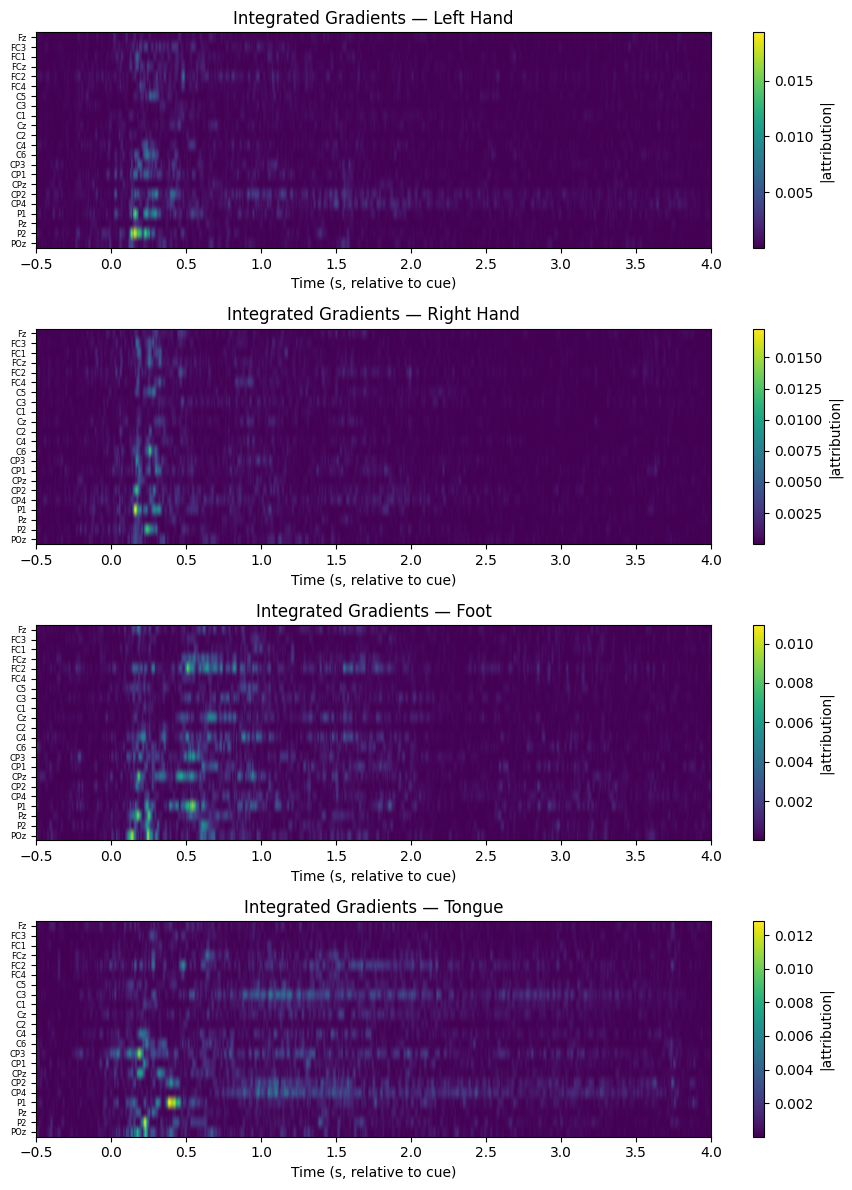

In [11]:
# ==========================================================
# Plot channel x time saliency (heatmap) per class
# ==========================================================

n_classes_with_saliency = len(class_saliency)
fig, axes = plt.subplots(n_classes_with_saliency, 1, figsize=(9, 3 * n_classes_with_saliency))
if n_classes_with_saliency == 1:
    axes = [axes]

for ax, (class_id, saliency) in zip(axes, class_saliency.items()):

    abs_saliency = np.abs(saliency)

    im = ax.imshow(abs_saliency, aspect="auto", cmap="viridis",
                    extent=[-0.5, 4.0, len(ch_names), 0])
    ax.set_yticks(np.arange(len(ch_names)) + 0.5)
    ax.set_yticklabels(ch_names, fontsize=6)
    ax.set_xlabel("Time (s, relative to cue)")
    ax.set_title(f"Integrated Gradients — {CLASS_NAMES[class_id]}")
    fig.colorbar(im, ax=ax, label="|attribution|")

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "kaelvornet_saliency_heatmaps.png", dpi=150)
plt.show()

---
## 2. Scalp Topomaps (Per-Class Channel Importance)

Aggregates each class's saliency over time (mean |attribution|), then projects it onto the
22-channel scalp layout using the same montage as the preprocessing pipeline.

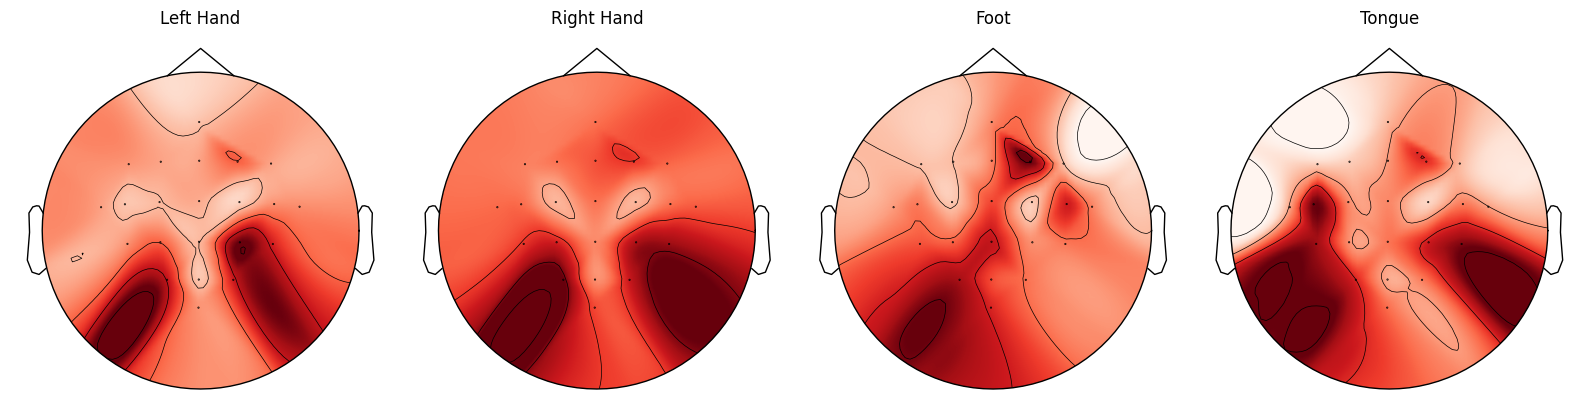

In [12]:
# ==========================================================
# Scalp Topomaps
# ==========================================================

info = mne.create_info(ch_names=ch_names, sfreq=250, ch_types="eeg")
montage = mne.channels.make_standard_montage("standard_1005")
info.set_montage(montage, match_case=False, on_missing="ignore")

fig, axes = plt.subplots(1, n_classes_with_saliency, figsize=(4 * n_classes_with_saliency, 4))
if n_classes_with_saliency == 1:
    axes = [axes]

for ax, (class_id, saliency) in zip(axes, class_saliency.items()):

    channel_importance = np.abs(saliency).mean(axis=1)  # mean over time -> (n_channels,)

    im, _ = mne.viz.plot_topomap(
        channel_importance, info, axes=ax, show=False, cmap="Reds", contours=4
    )
    ax.set_title(CLASS_NAMES[class_id])

plt.tight_layout()
plt.savefig(OUTPUT_PATH / "kaelvornet_saliency_topomaps.png", dpi=150)
plt.show()

---
## 3. Subject-Invariance Probe

Extracts backbone features (pre-adapter -- what the domain head actually sees) for a pooled
set of trials with known subject labels, from **both** models, and trains a simple linear
probe (logistic regression) to predict subject identity from those features. If GRL worked,
the probe's accuracy on the full-KaelvorNet features should be noticeably lower (closer to
chance, 1/n_subjects) than on the plain-EEGNet features.

In [13]:
# ==========================================================
# Extract Backbone Features for the Probe
# ==========================================================

def extract_backbone_features(model, X, mean, std, batch_size=64):

    X_norm = normalize(X, mean, std)
    features = []

    model.eval()
    with torch.no_grad():
        for i in range(0, len(X_norm), batch_size):
            xb = torch.tensor(X_norm[i:i+batch_size], dtype=torch.float32).to(DEVICE)
            feat = model.get_features(xb)
            features.append(feat.cpu().numpy())

    return np.concatenate(features, axis=0)


# Use the pretraining pool (8 subjects, known subject labels) for both models --
# this is exactly the population the domain head was trained to confuse.
features_full = extract_backbone_features(model_full, X_pool_a, mean_full, std_full)
features_plain = extract_backbone_features(model_plain, X_pool_b, mean_plain, std_plain)

print(f"Full KaelvorNet features shape : {features_full.shape}")
print(f"Plain EEGNet features shape    : {features_plain.shape}")

Full KaelvorNet features shape : (2304, 560)
Plain EEGNet features shape    : (2304, 560)


In [14]:
# ==========================================================
# Fit Subject-ID Probes and Compare
# ==========================================================

def probe_subject_id(features, subject_labels, seed=SEED):

    X_tr, X_te, y_tr, y_te = train_test_split(
        features, subject_labels, test_size=0.3, stratify=subject_labels, random_state=seed
    )

    probe = LogisticRegression(max_iter=2000, random_state=seed)
    probe.fit(X_tr, y_tr)

    return accuracy_score(y_te, probe.predict(X_te))


probe_acc_full = probe_subject_id(features_full, subj_pool_a)
probe_acc_plain = probe_subject_id(features_plain, subj_pool_b)

chance_level = 1.0 / len(train_subject_ids)

print("=" * 70)
print("SUBJECT-INVARIANCE PROBE")
print("=" * 70)
print(f"Chance level (random guessing among {len(train_subject_ids)} subjects): {chance_level:.3f}")
print(f"Probe accuracy on PLAIN EEGNet features (no GRL) : {probe_acc_plain:.3f}")
print(f"Probe accuracy on FULL KaelvorNet features (GRL) : {probe_acc_full:.3f}")

if probe_acc_full < probe_acc_plain:
    print(f"\nGRL reduced subject decodability by {probe_acc_plain - probe_acc_full:.3f} "
          f"(closer to chance = more subject-invariant).")
else:
    print("\nGRL did NOT reduce subject decodability here -- consider a longer domain-loss "
          "ramp-up, a larger grl_lambda_max, or more pretraining epochs.")

probe_results = pd.DataFrame([
    {"Model": "Plain EEGNet (no GRL)", "Subject_ID_Probe_Accuracy": probe_acc_plain},
    {"Model": "Full KaelvorNet (GRL)", "Subject_ID_Probe_Accuracy": probe_acc_full},
    {"Model": "Chance level", "Subject_ID_Probe_Accuracy": chance_level},
])

display(probe_results)
probe_results.to_csv(OUTPUT_PATH / "kaelvornet_subject_invariance_probe.csv", index=False)

SUBJECT-INVARIANCE PROBE
Chance level (random guessing among 8 subjects): 0.125
Probe accuracy on PLAIN EEGNet features (no GRL) : 0.918
Probe accuracy on FULL KaelvorNet features (GRL) : 0.640

GRL reduced subject decodability by 0.277 (closer to chance = more subject-invariant).


,Model,Subject_ID_Probe_Accuracy
0,Plain EEGNet (no GRL),0.917630
1,Full KaelvorNet (GRL),0.640173
2,Chance level,0.125000


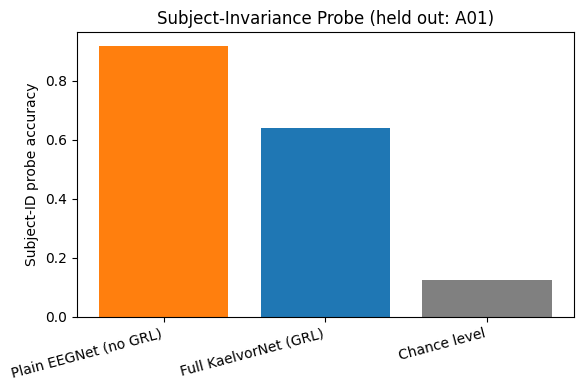

In [15]:
# ==========================================================
# Visualize the probe comparison
# ==========================================================

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(probe_results["Model"], probe_results["Subject_ID_Probe_Accuracy"],
              color=["tab:orange", "tab:blue", "gray"])

ax.set_ylabel("Subject-ID probe accuracy")
ax.set_title(f"Subject-Invariance Probe (held out: {HELD_OUT_SUBJECT})")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_PATH / "kaelvornet_subject_invariance_chart.png", dpi=150)
plt.show()